#**🚀 Phishing Detection: Model Interpretability & Deployment Report**
---

#**✅ 1. Handle Missing Values & Remove Duplicates**

In [ ]:
import pandas as pd

# Load dataset
df = pd.read_csv('dataset_phishing.csv')

# Remove unnamed columns if any
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

# Convert columns to lowercase for consistency
df.columns = df.columns.str.lower()

# Check missing values
print("Missing Values:\n", df.isnull().sum())

# Fill missing values (use mean for numeric, mode for categorical)
for col in df.columns:
    if df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])
    else:
        df[col] = df[col].fillna(df[col].mean())

# Remove duplicate rows
duplicates = df.duplicated().sum()
df = df.drop_duplicates()
print(f"Removed {duplicates} duplicate rows")


Missing Values:
 url                0
length_url         0
length_hostname    0
ip                 0
nb_dots            0
                  ..
web_traffic        0
dns_record         0
google_index       0
page_rank          0
status             0
Length: 89, dtype: int64
Removed 0 duplicate rows


#**✅ 2. Feature Encoding for Categorical Variables**

In [ ]:
# Label encode binary categorical columns
from sklearn.preprocessing import LabelEncoder

label_enc = LabelEncoder()
for col in df.select_dtypes(include='object'):
    df[col] = label_enc.fit_transform(df[col])


#**✅ 3. Normalize/Scale Numerical Features**

In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
numeric_cols = df.select_dtypes(include='number').columns.tolist()
numeric_cols.remove('status')  # exclude target column

df[numeric_cols] = scaler.fit_transform(df[numeric_cols])


#**✅ 4. Split Dataset into Training and Testing**

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('status', axis=1)
y = df['status']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print("Training set size:", X_train.shape)
print("Testing set size:", X_test.shape)


Training set size: (9144, 88)
Testing set size: (2286, 88)


#**🧮 1. Summary Statistics for Numerical Features**

In [ ]:
import pandas as pd

# Load the dataset
df = pd.read_csv('dataset_phishing.csv')

# Summary statistics
numerical_summary = df.describe().T[['mean', '50%', 'std', 'min', 'max']]
numerical_summary.rename(columns={'50%': 'median'}, inplace=True)
print("📊 Summary Statistics for Numerical Features:\n")
print(numerical_summary)


📊 Summary Statistics for Numerical Features:

                          mean  median           std   min         max
length_url           61.126684    47.0  5.529732e+01  12.0      1641.0
length_hostname      21.090289    19.0  1.077717e+01   4.0       214.0
ip                    0.150569     0.0  3.576436e-01   0.0         1.0
nb_dots               2.480752     2.0  1.369686e+00   1.0        24.0
nb_hyphens            0.997550     0.0  2.087087e+00   0.0        43.0
...                        ...     ...           ...   ...         ...
domain_age         4062.543745  3993.0  3.107785e+03 -12.0     12874.0
web_traffic      856756.643307  1651.0  1.995606e+06   0.0  10767986.0
dns_record            0.020122     0.0  1.404254e-01   0.0         1.0
google_index          0.533946     1.0  4.988682e-01   0.0         1.0
page_rank             3.185739     3.0  2.536955e+00   0.0        10.0

[87 rows x 5 columns]


#**🔣 2. Frequency Distribution & Mode for Categorical Features**

In [ ]:
# Identify categorical columns
categorical_cols = df.select_dtypes(include='object').columns.tolist()

# Frequency distribution and mode
print("\n📋 Frequency Distribution and Mode for Categorical Features:\n")
for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Mode:", df[col].mode()[0])
    print(df[col].value_counts())



📋 Frequency Distribution and Mode for Categorical Features:


Column: url
Mode: http://e710z0ear.du.r.appspot.com/c:/users/user/downlo
url
http://e710z0ear.du.r.appspot.com/c:/users/user/downlo                                                                                           2
http://office365-login-outlook.el.r.appspot.com/wp-content/xp.php                                                                                1
http://graceleadershipfoundation.org/modules/mod_simplefileuploadv1.3/connect/                                                                   1
http://fience.vot.pl/xl                                                                                                                          1
https://usbank.app.link/NquAmzCW01?platform=hootsuite                                                                                            1
                                                                                                                             

#**📊 3. Visual Analysis Report**

**A. Histograms**

<ipython-input-7-e196eaaad496>:6: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


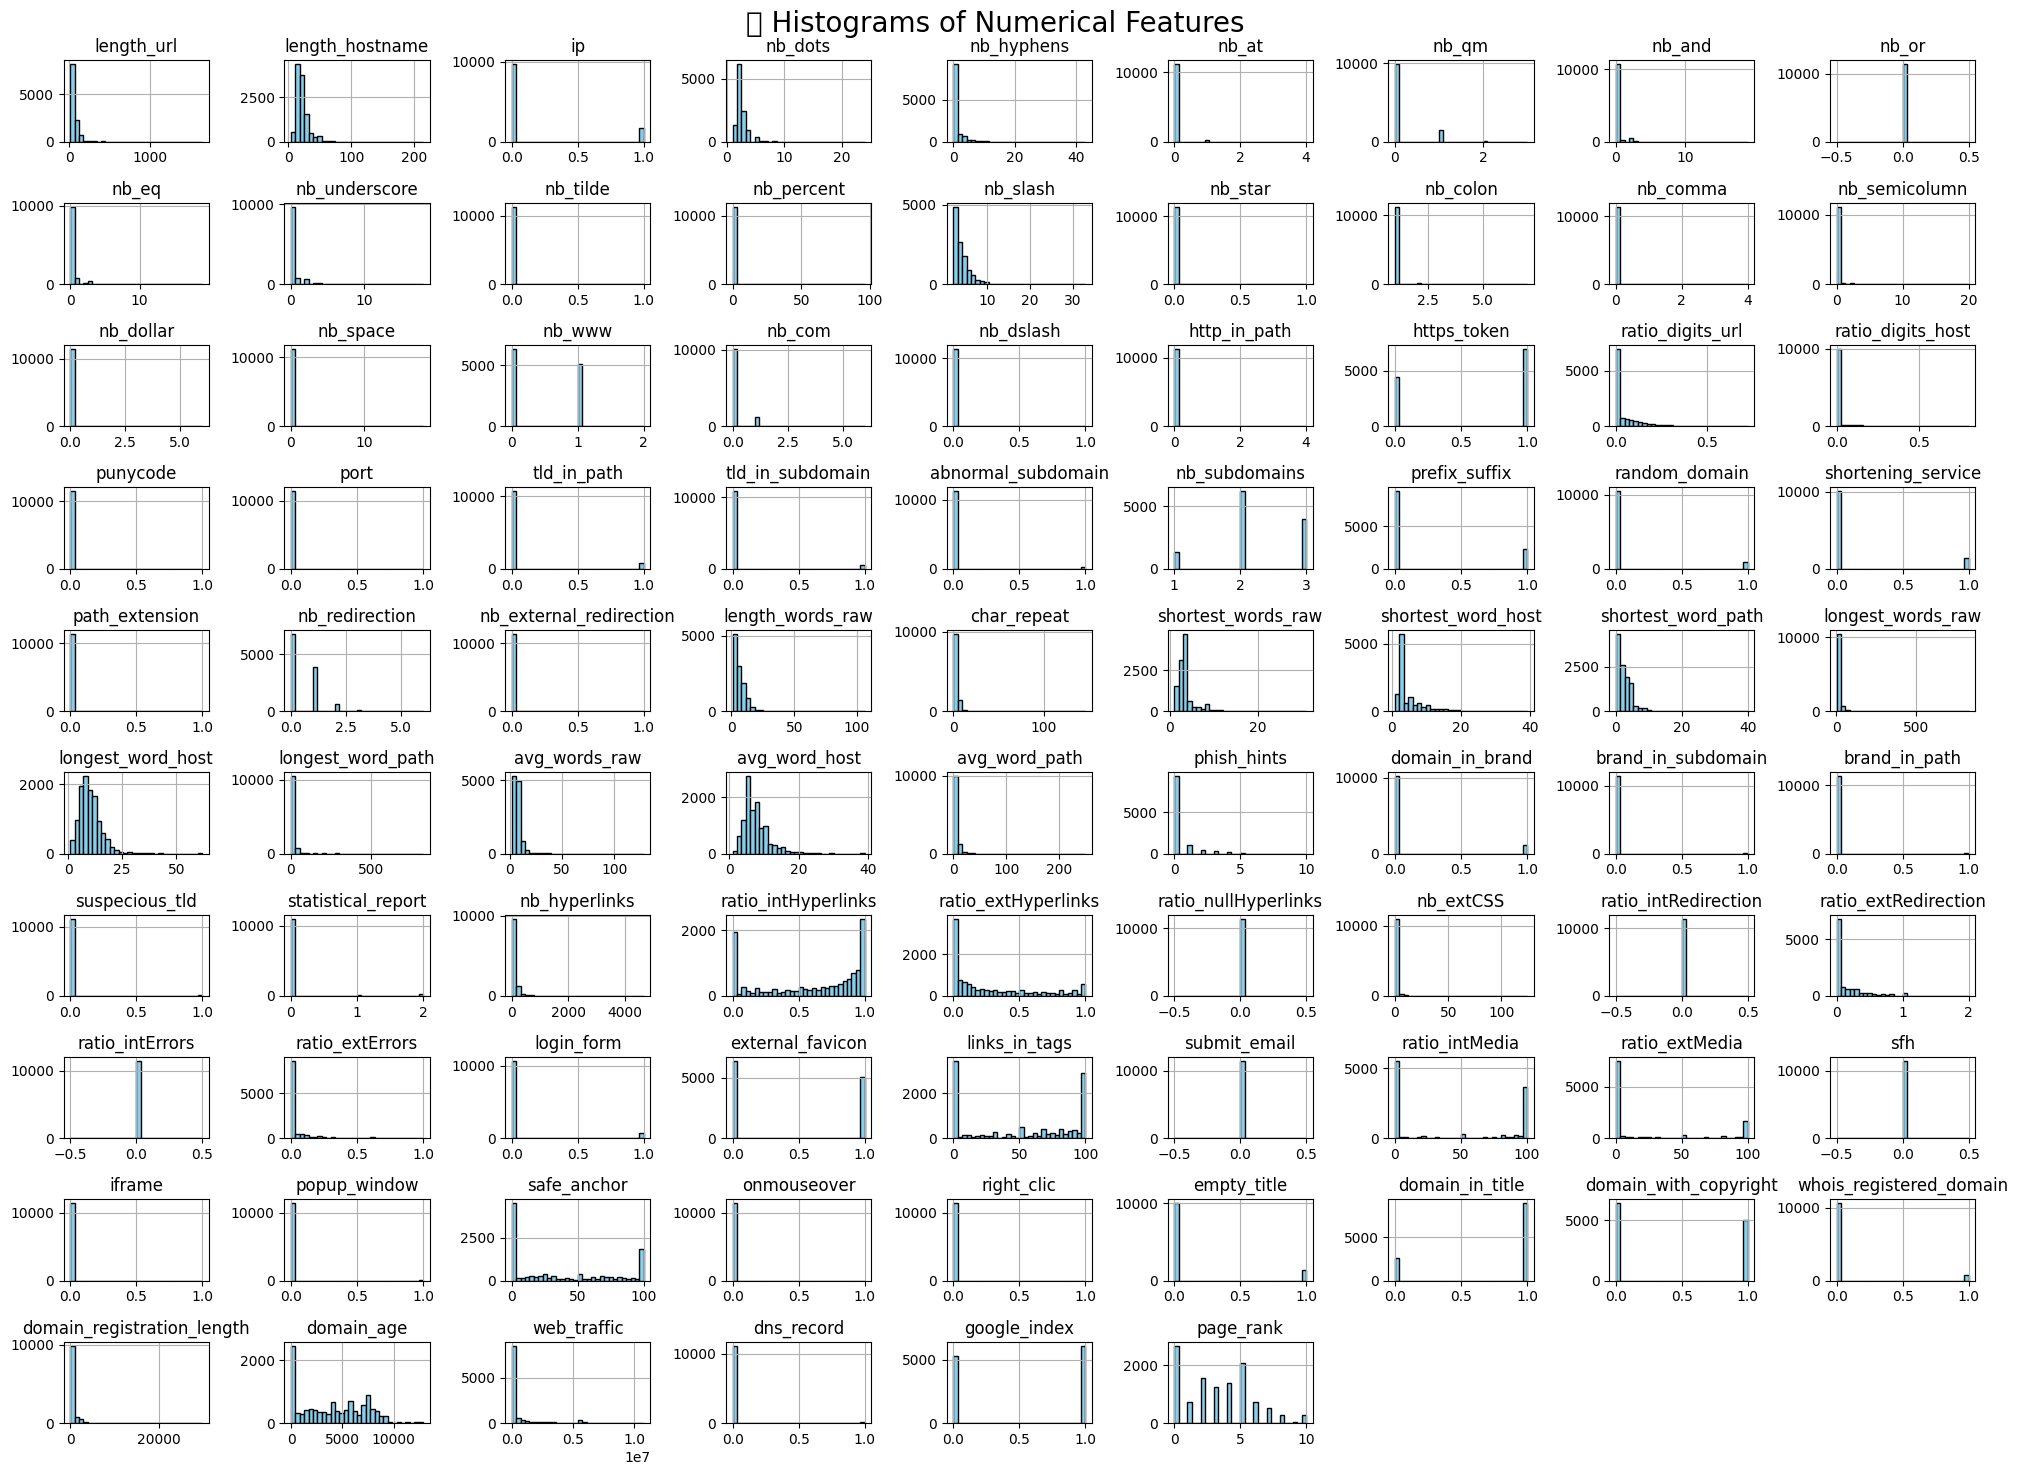

In [ ]:
import matplotlib.pyplot as plt

# Plot histograms for all numerical columns
df.hist(bins=30, figsize=(20, 15), color='skyblue', edgecolor='black')
plt.suptitle("🔍 Histograms of Numerical Features", fontsize=20)
plt.tight_layout()
plt.show()


**B. Pair Plots**

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128279 (\N{LINK SYMBOL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


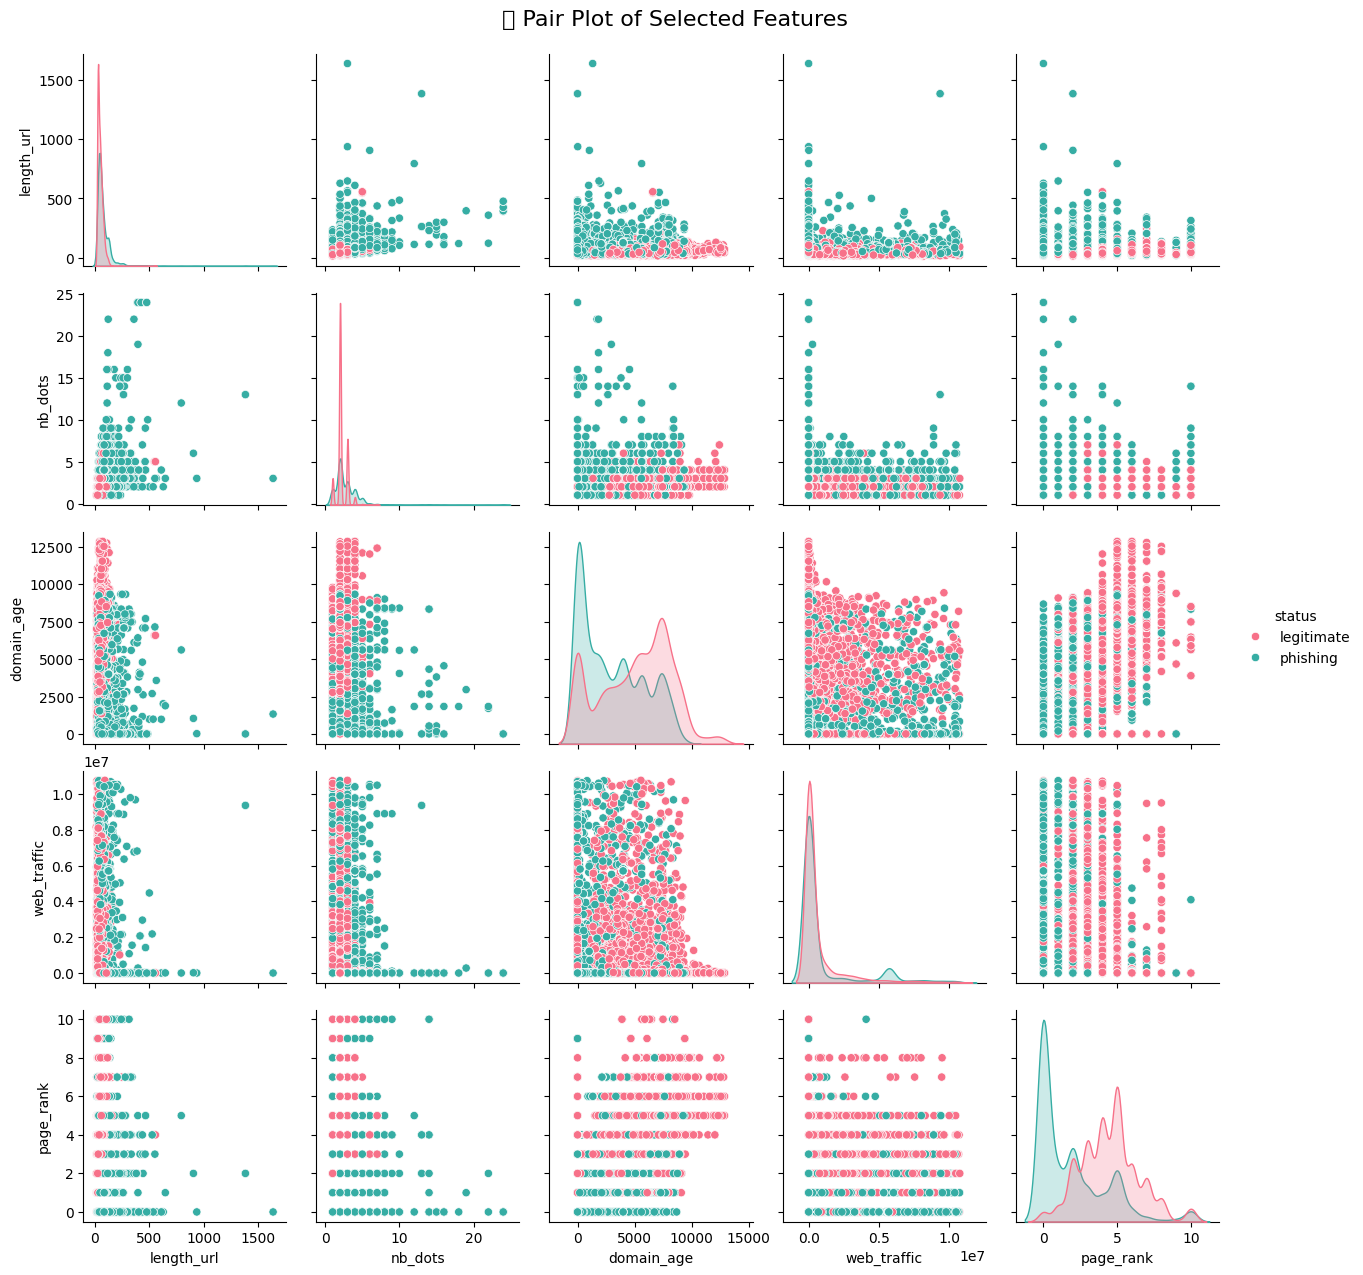

In [ ]:
import seaborn as sns

# Convert target variable to categorical if needed
df['status'] = df['status'].astype('category')

# Select sample columns for pairplot
sample_cols = ['length_url', 'nb_dots', 'domain_age', 'web_traffic', 'page_rank', 'status']

# Pair plot
sns.pairplot(df[sample_cols], hue='status', palette='husl')
plt.suptitle("🔗 Pair Plot of Selected Features", y=1.02, fontsize=16)
plt.show()


**C. Heatmap (Correlation Matrix)**

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128293 (\N{FIRE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


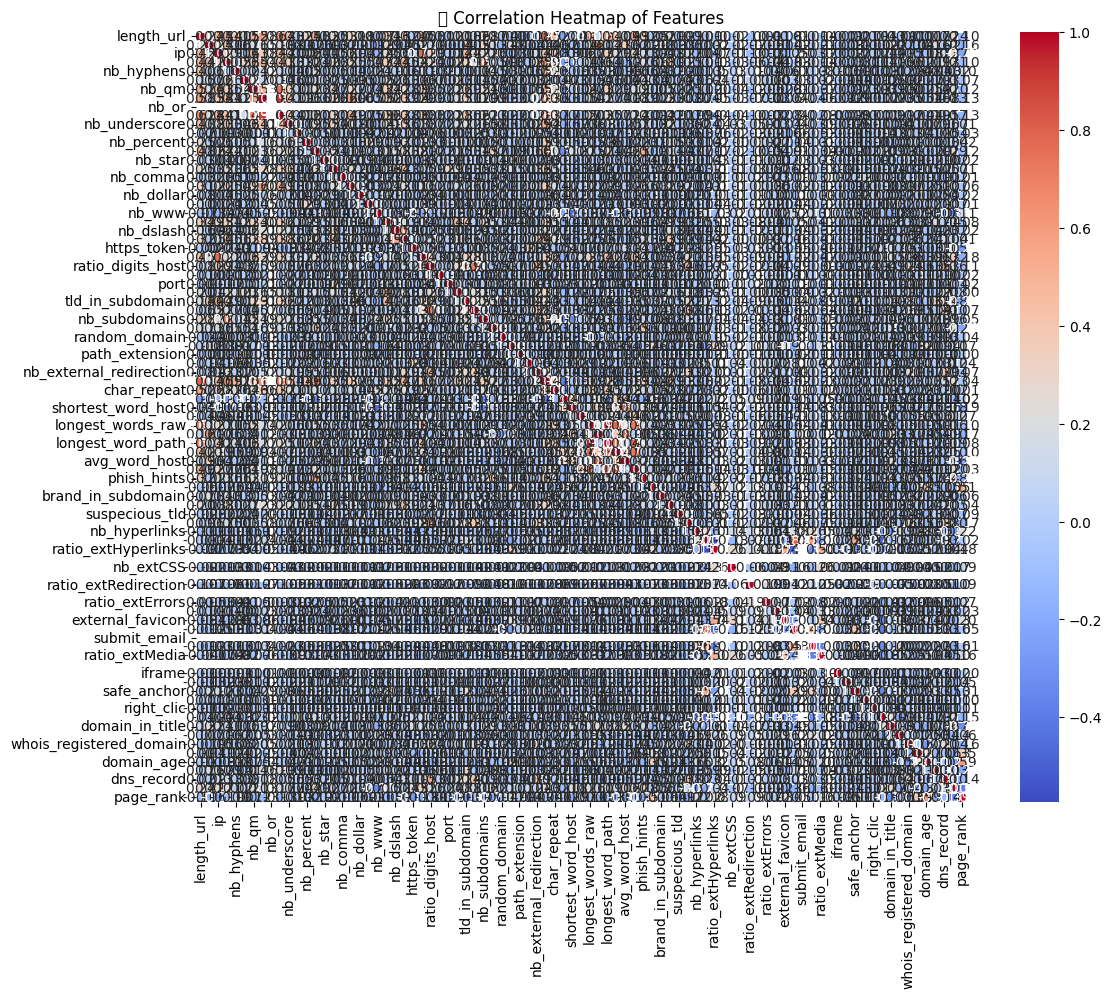

In [ ]:
# Compute and plot correlation heatmap
correlation_matrix = df.corr(numeric_only=True)

plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True, linewidths=0.5)
plt.title("🔥 Correlation Heatmap of Features")
plt.show()


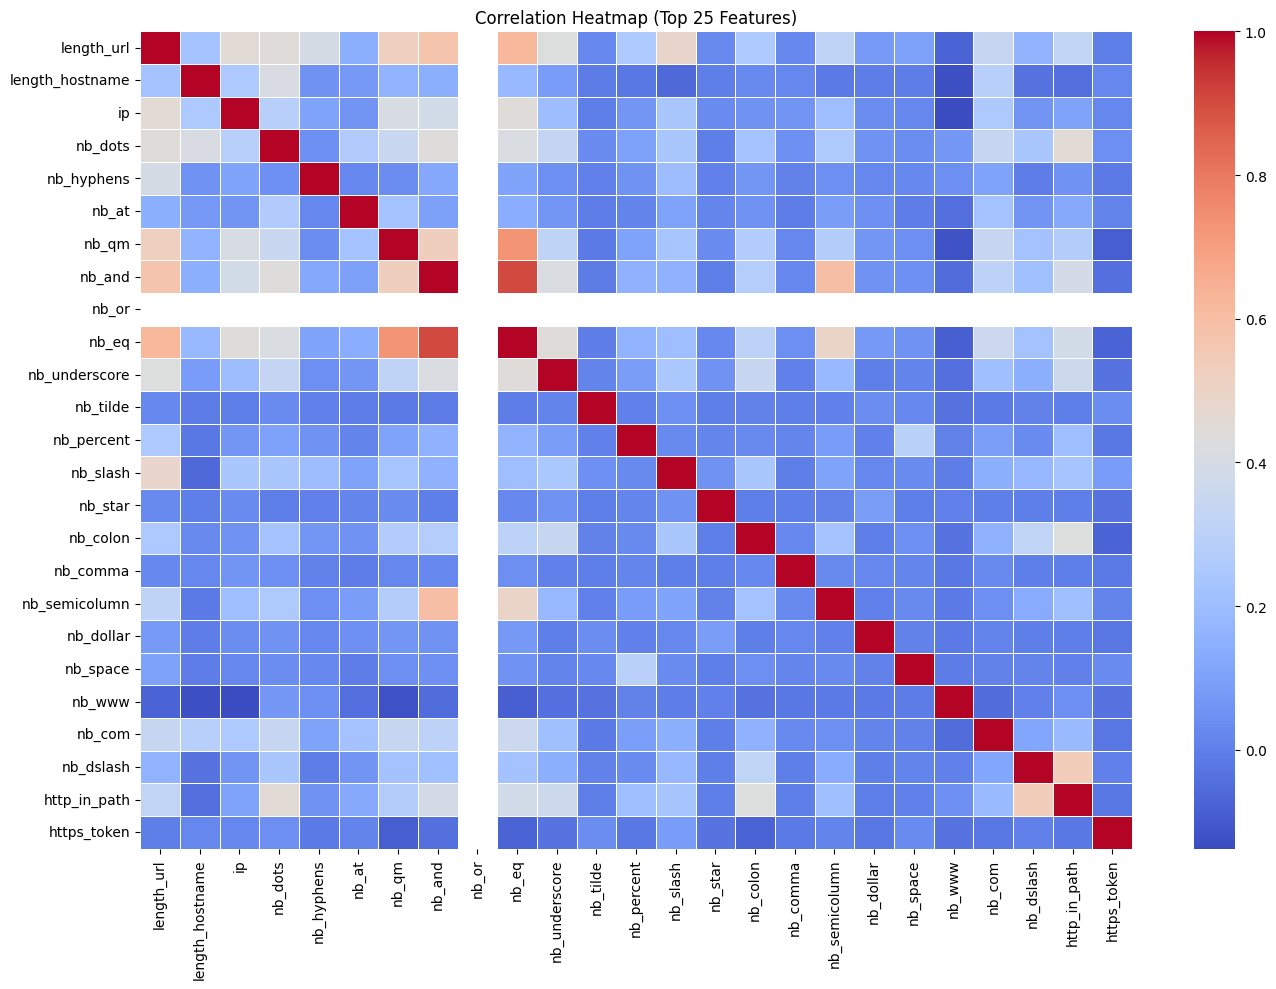

Top Highly Correlated Pairs:
            Feature_1          Feature_2  Correlation
46  longest_words_raw  longest_word_path     0.968503
8              nb_and              nb_eq     0.906404


In [ ]:
# 1. Import Required Libraries
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 2. Load the Dataset
df = pd.read_csv("dataset_phishing.csv")  # Make sure this CSV file is in the same directory or provide full path

# 3. Encode Target Variable for Correlation
df_corr = df.copy()
df_corr['status'] = df_corr['status'].map({'legitimate': 0, 'phishing': 1})  # Encoding status to numeric

# 4. Generate Correlation Matrix
correlation_matrix = df_corr.corr(numeric_only=True)

# 5. Visualize a Subset Correlation Heatmap
plt.figure(figsize=(14, 10))
sns.heatmap(correlation_matrix.iloc[:25, :25], annot=False, cmap="coolwarm", linewidths=0.5)
plt.title("Correlation Heatmap (Top 25 Features)")
plt.tight_layout()
plt.show()

# 6. Identify Highly Correlated Feature Pairs (|correlation| > 0.85)
high_corr_pairs = (
    correlation_matrix.where(lambda x: abs(x) > 0.85)
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Feature_1"] != high_corr_pairs["Feature_2"]]
high_corr_pairs = high_corr_pairs.drop_duplicates(subset=["Correlation"])
print("Top Highly Correlated Pairs:")
print(high_corr_pairs.sort_values(by="Correlation", ascending=False).head(10))


In [ ]:
# Identify highly correlated pairs
high_corr_pairs = (
    correlation_matrix.where(lambda x: abs(x) > 0.85)
    .stack()
    .reset_index()
)
high_corr_pairs.columns = ["Feature_1", "Feature_2", "Correlation"]
high_corr_pairs = high_corr_pairs[high_corr_pairs["Feature_1"] != high_corr_pairs["Feature_2"]]
high_corr_pairs = high_corr_pairs.drop_duplicates(subset=["Correlation"])
high_corr_pairs.sort_values(by="Correlation", ascending=False).head(10)


,Feature_1,Feature_2,Correlation
46,longest_words_raw,longest_word_path,0.968503
8,nb_and,nb_eq,0.906404


In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder
import pandas as pd

# Load the dataset
df = pd.read_csv("dataset_phishing.csv")

# Encode target variable
df_encoded = df.copy()
df_encoded['status'] = df_encoded['status'].map({'legitimate': 0, 'phishing': 1})

# Feature matrix and target
X = df_encoded.drop(columns=['status', 'url'])  # Drop non-numeric and target column
y = df_encoded['status']
X = X.fillna(0)  # Handle missing values

# Feature importance via Random Forest
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X, y)
rf_importances = pd.Series(rf.feature_importances_, index=X.columns).sort_values(ascending=False)

# Feature importance via Mutual Information
mi = mutual_info_classif(X, y, discrete_features='auto', random_state=42)
mi_series = pd.Series(mi, index=X.columns).sort_values(ascending=False)

# Combined feature importance
feature_importance_df = pd.DataFrame({
    'RandomForestImportance': rf_importances,
    'MutualInformation': mi_series
}).sort_values(by='RandomForestImportance', ascending=False)

# Identify low-impact features
low_impact_features = feature_importance_df[
    (feature_importance_df['RandomForestImportance'] < 0.005) &
    (feature_importance_df['MutualInformation'] < 0.01)
].index.tolist()



Model Evaluation Results:
                  Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
4              XGBoost  0.973316   0.974245  0.971656  0.972949  0.995589
2        Random Forest  0.969379   0.974888  0.962799  0.968806  0.994460
1        Decision Tree  0.935696   0.933746  0.936227  0.934985  0.935702
0  Logistic Regression  0.815398   0.813109  0.813109  0.813109  0.889160
3                  SVM  0.595801   0.557231  0.883968  0.683562  0.781913


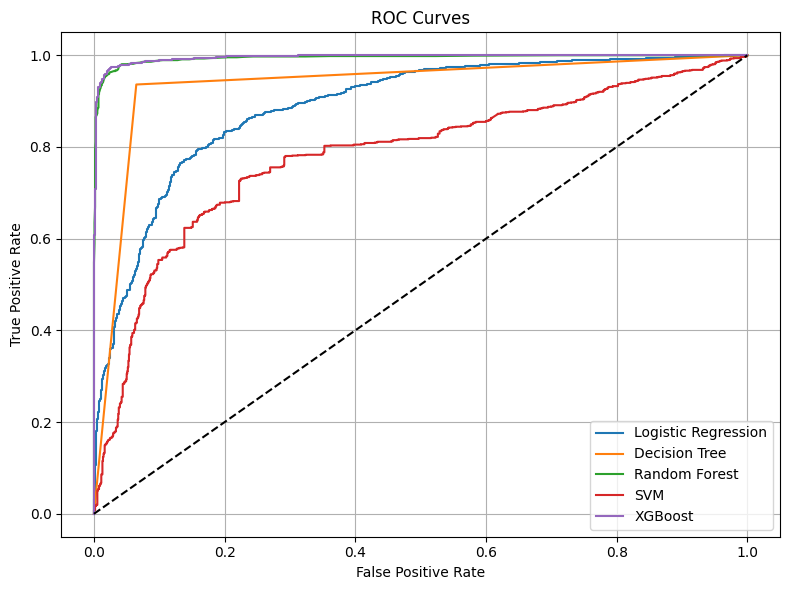

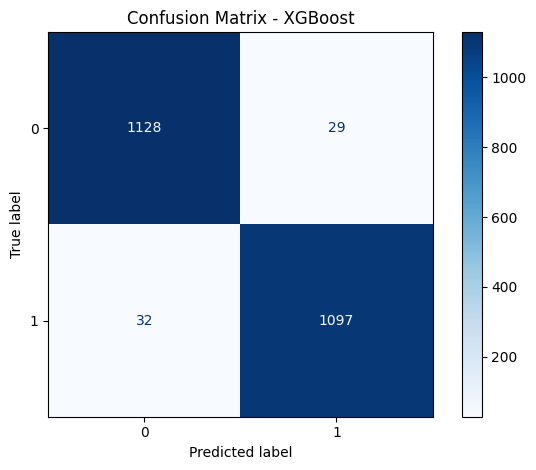

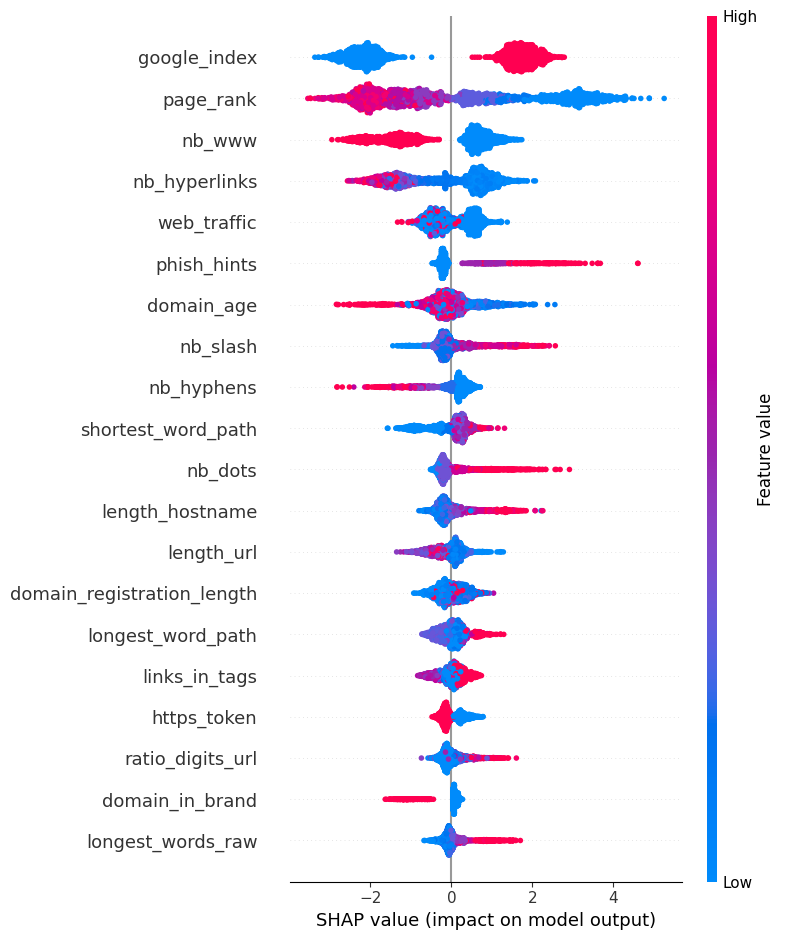

In [ ]:
# ----------------------------
# 1. Import Libraries
# ----------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, roc_curve
)

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
import shap
import warnings
warnings.filterwarnings("ignore")

# ----------------------------
# 2. Load & Preprocess Dataset
# ----------------------------
df = pd.read_csv("dataset_phishing.csv")  # Replace with your path
df.dropna(inplace=True)

# Encode the target variable
le = LabelEncoder()
df['status'] = le.fit_transform(df['status'])  # 0 = legitimate, 1 = phishing

# Drop non-numeric columns (e.g., 'url', 'domain') for ML models
non_numeric_cols = df.select_dtypes(include=['object']).columns
df = df.drop(columns=non_numeric_cols)

# Define features and target
X = df.drop('status', axis=1)
y = df['status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# ----------------------------
# 3. Train Models
# ----------------------------
models = {
    "Logistic Regression": LogisticRegression(max_iter=1000),
    "Decision Tree": DecisionTreeClassifier(random_state=42),
    "Random Forest": RandomForestClassifier(random_state=42),
    "SVM": SVC(probability=True, random_state=42),
    "XGBoost": XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=42)
}

results = []
roc_data = {}
conf_matrices = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall": recall_score(y_test, y_pred),
        "F1 Score": f1_score(y_test, y_pred),
        "ROC-AUC": roc_auc_score(y_test, y_proba)
    })

    # Store for visualizations
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_data[name] = (fpr, tpr)
    conf_matrices[name] = confusion_matrix(y_test, y_pred)

# ----------------------------
# 4. Evaluation Table
# ----------------------------
results_df = pd.DataFrame(results).sort_values(by='ROC-AUC', ascending=False)
print("\nModel Evaluation Results:\n", results_df)

# ----------------------------
# 5. Save the Best Model (XGBoost)
# ----------------------------
best_model = models['XGBoost']
joblib.dump(best_model, 'phishing_detector_model.pkl')  # Saved as .pkl

# ----------------------------
# 6. ROC Curve Plot
# ----------------------------
plt.figure(figsize=(8, 6))
for name, (fpr, tpr) in roc_data.items():
    plt.plot(fpr, tpr, label=f'{name}')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.savefig('roc_curves.png')
plt.show()

# ----------------------------
# 7. Confusion Matrix for Best Model
# ----------------------------
disp = ConfusionMatrixDisplay(confusion_matrix=conf_matrices['XGBoost'], display_labels=best_model.classes_)
disp.plot(cmap=plt.cm.Blues)
plt.title('Confusion Matrix - XGBoost')
plt.tight_layout()
plt.savefig('confusion_matrix_xgb.png')
plt.show()

# ----------------------------
# 8. Feature Importance with SHAP
# ----------------------------
explainer = shap.Explainer(best_model)
shap_values = explainer(X_test)

# SHAP Summary Plot
shap.summary_plot(shap_values, X_test, show=False)
plt.tight_layout()
plt.savefig('shap_summary.png')
plt.show()


In [ ]:
import pandas as pd

# Load the correct dataset
data = pd.read_csv("/content/dataset_phishing.csv")  # <- Adjust path if different

# Display a preview
data.head()


,url,length_url,length_hostname,ip,nb_dots,nb_hyphens,nb_at,nb_qm,nb_and,nb_or,...,domain_in_title,domain_with_copyright,whois_registered_domain,domain_registration_length,domain_age,web_traffic,dns_record,google_index,page_rank,status
0,http://www.crestonwood.com/router.php,37,19,0,3,0,0,0,0,0,...,0,1,0,45,-1,0,1,1,4,legitimate
1,http://shadetreetechnology.com/V4/validation/a...,77,23,1,1,0,0,0,0,0,...,1,0,0,77,5767,0,0,1,2,phishing
2,https://support-appleld.com.secureupdate.duila...,126,50,1,4,1,0,1,2,0,...,1,0,0,14,4004,5828815,0,1,0,phishing
3,http://rgipt.ac.in,18,11,0,2,0,0,0,0,0,...,1,0,0,62,-1,107721,0,0,3,legitimate
4,http://www.iracing.com/tracks/gateway-motorspo...,55,15,0,2,2,0,0,0,0,...,0,1,0,224,8175,8725,0,0,6,legitimate


In [ ]:
# Drop the URL column if present (non-numeric, causes errors)
if 'url' in data.columns:
    data = data.drop('url', axis=1)

# Separate features and target
X = data.drop("status", axis=1)
y = data["status"]


In [ ]:
import joblib

# Load saved model
model = joblib.load("/content/phishing_detector_model.pkl")  # Change path if needed


In [ ]:
joblib.dump(model, "phishing_detector_model.pkl")


['phishing_detector_model.pkl']

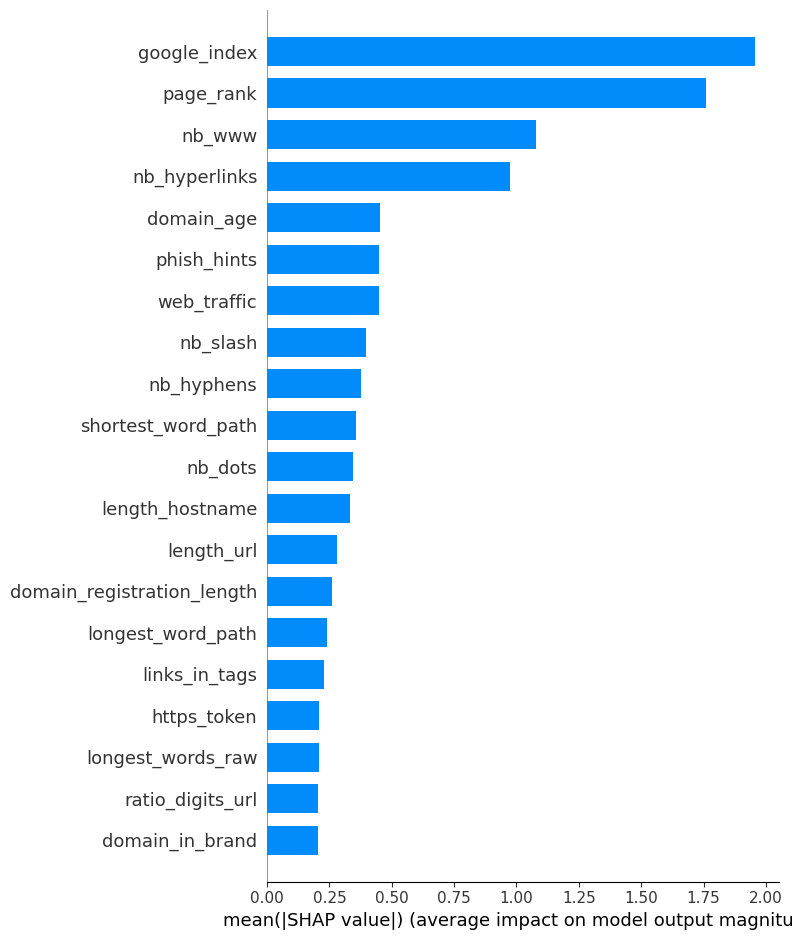

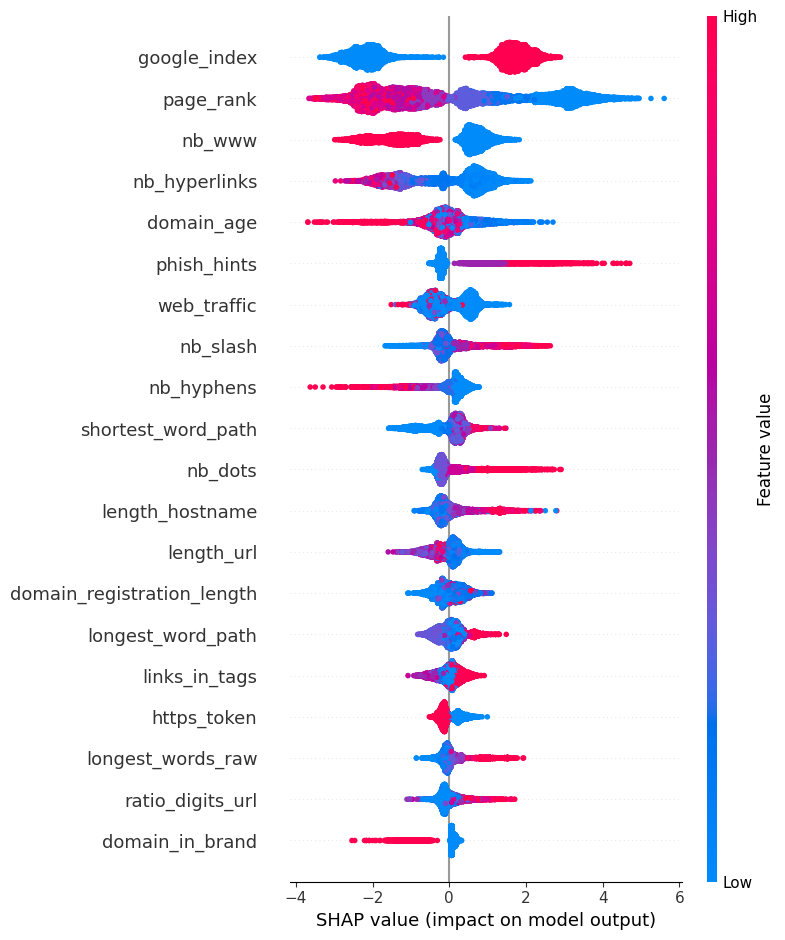

In [ ]:
import shap
import matplotlib.pyplot as plt

# Create a SHAP explainer
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Global feature importance plot (bar)
shap.summary_plot(shap_values, X, plot_type="bar")
plt.savefig("shap_summary_plot.png")

# Beeswarm for detailed visualization
shap.summary_plot(shap_values, X)

# Local explanation for a single prediction
sample_index = 5
shap.initjs()
force_plot = shap.force_plot(explainer.expected_value, shap_values[sample_index], X.iloc[sample_index])
shap.save_html("shap_force_plot.html", force_plot)


In [ ]:
import shap
import pickle

# Recreate SHAP explainer
explainer = shap.TreeExplainer(model)

# Save it again
with open("explainer_shap.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("✅ SHAP explainer recreated and saved successfully!")


✅ SHAP explainer recreated and saved successfully!


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Get shap values
shap_values = explainer.shap_values(X_train)

# Handle both single array and list of arrays (for binary classification)
if isinstance(shap_values, list) and len(shap_values) == 2:
    shap_summary = shap_values[1]  # use class 1 SHAP values
else:
    shap_summary = shap_values     # use directly if it's a single matrix

# Ensure it's a matrix (2D)
assert len(np.shape(shap_summary)) == 2, "SHAP summary values must be a matrix"

# Plot summary
shap.summary_plot(shap_summary, X_train, plot_type="bar", show=False)
plt.savefig("shap_summary_plot.png")
plt.close()

print("📊 SHAP summary plot saved as 'shap_summary_plot.png'")


📊 SHAP summary plot saved as 'shap_summary_plot.png'


In [ ]:
from flask import Flask, request, jsonify, render_template
import pickle
import pandas as pd
import shap
import numpy as np

app = Flask(__name__)

# Load model and SHAP explainer
model = pickle.load(open("phishing_detector_model.pkl", "rb"))
explainer = pickle.load(open("explainer_shap.pkl", "rb"))  # Ensure this file exists in the same directory

@app.route('/')
def home():
    return render_template('index.html')

@app.route('/predict', methods=["POST"])
def predict():
    try:
        data = request.form.to_dict()
        df = pd.DataFrame([data])
        for col in df.columns:
            df[col] = pd.to_numeric(df[col], errors='coerce')

        prediction = model.predict(df)[0]
        proba = model.predict_proba(df)[0][1]

        return jsonify({
            "prediction": int(prediction),
            "probability": float(proba)
        })

    except Exception as e:
        return jsonify({"error": str(e)})

@app.route('/explain', methods=["POST"])
def explain():
    data = request.form.to_dict()
    df = pd.DataFrame([data])
    for col in df.columns:
        df[col] = pd.to_numeric(df[col], errors='coerce')

    shap_values = explainer.shap_values(df)
    shap_html = shap.plots.force(explainer.expected_value[1], shap_values[1][0, :], df.iloc[0, :], matplotlib=False)
    with open("static/shap_output.html", "w") as f:
        f.write(shap_html.html())

    return render_template("shap_output.html")

if __name__ == '__main__':
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat


Classification Report:
               precision    recall  f1-score   support

  legitimate       0.96      0.98      0.97      1157
    phishing       0.97      0.96      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286

ROC AUC Score: 0.9944604911912164


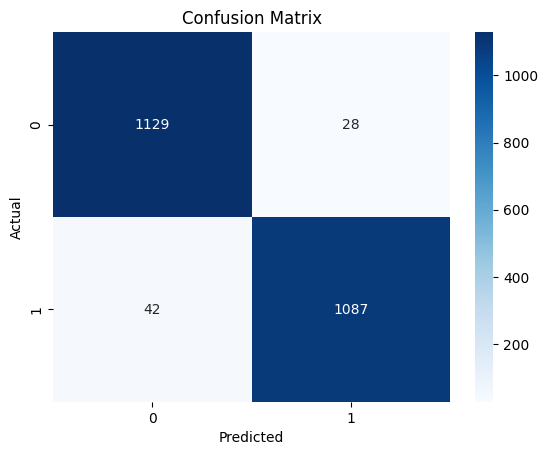

In [ ]:
import pandas as pd
import numpy as np
import shap
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("dataset_phishing.csv")

# Separate features and target
X = data.drop(columns=['url', 'status'])  # Drop URL and keep only numerical features
y = data['status']  # Target variable

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Evaluate model
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


<Figure size 640x480 with 0 Axes>

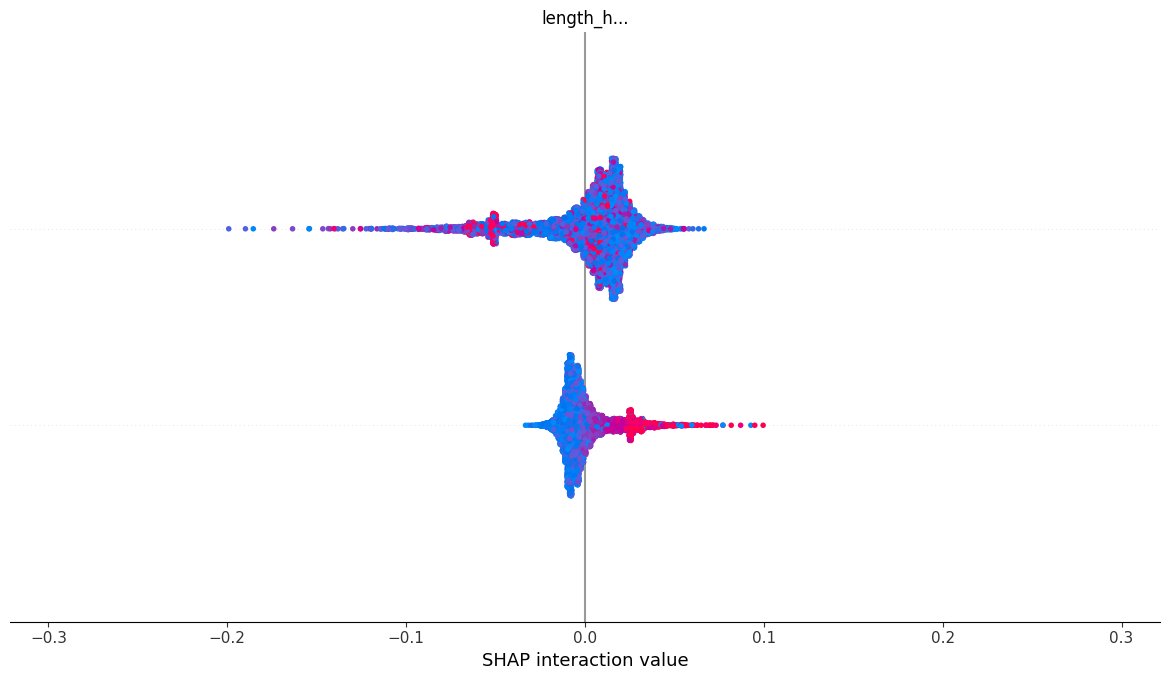

✅ Model and SHAP explainer saved successfully!


In [ ]:
# SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# SHAP Summary Plot for binary classification (use class 0 or 1 based on model behavior)
shap.summary_plot(shap_values, X_train, plot_type="bar")

# Save model and explainer
import pickle
pickle.dump(model, open("phishing_model.pkl", "wb"))
pickle.dump(explainer, open("explainer_shap.pkl", "wb"))

print("✅ Model and SHAP explainer saved successfully!")


In [ ]:
print("X_train shape:", X_train.shape)
print("SHAP values shape:")
if isinstance(shap_values, list):
    print("List of", len(shap_values), "arrays")
    print("shap_values[0] shape:", shap_values[0].shape)
    print("shap_values[1] shape:", shap_values[1].shape)
else:
    print("shap_values shape:", shap_values.shape)


X_train shape: (9144, 87)
SHAP values shape:
shap_values shape: (9144, 87, 2)


SHAP values shape: (9144, 87, 2)
X_train shape: (9144, 87)


<Figure size 640x480 with 0 Axes>

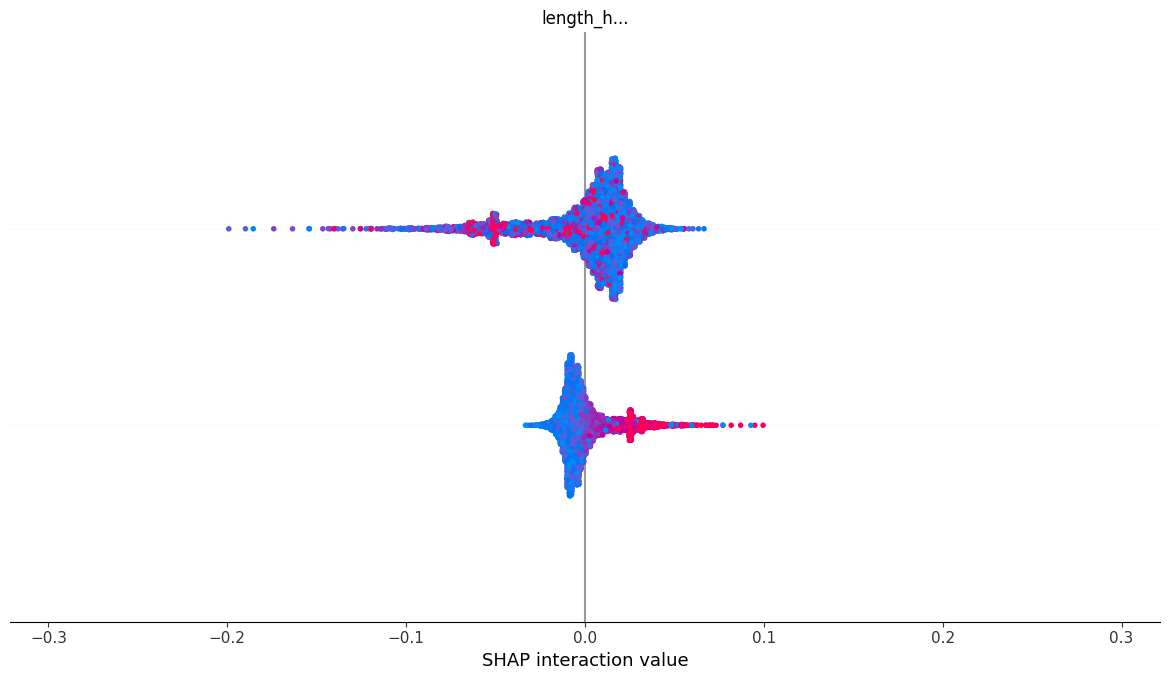

In [ ]:
# SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# Check and reshape if needed
if isinstance(shap_values, list):
    shap_values_to_plot = shap_values[1]  # Class 1
else:
    shap_values_to_plot = shap_values

# Now make sure shape matches
print("SHAP values shape:", shap_values_to_plot.shape)
print("X_train shape:", X_train.shape)

# SHAP Summary Plot
shap.summary_plot(shap_values_to_plot, X_train, plot_type="bar")


Classification Report:
               precision    recall  f1-score   support

  legitimate       0.96      0.98      0.97      1157
    phishing       0.97      0.96      0.97      1129

    accuracy                           0.97      2286
   macro avg       0.97      0.97      0.97      2286
weighted avg       0.97      0.97      0.97      2286

ROC AUC Score: 0.9944604911912164


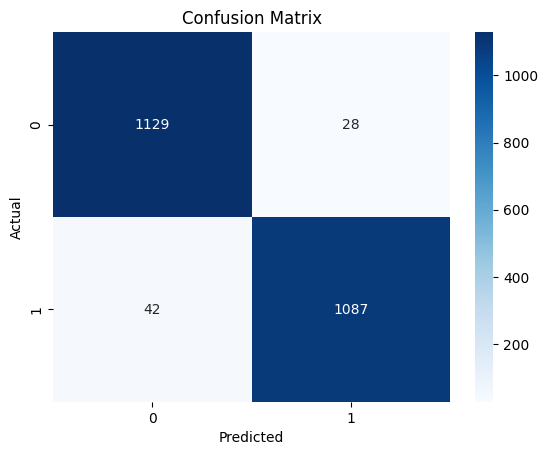

In [ ]:
# train_and_explain.py

import pandas as pd
import numpy as np
import shap
import pickle
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
data = pd.read_csv("dataset_phishing.csv")

# Separate features and target
X = data.drop(columns=["url", "status"])
y = data["status"]

# Split dataset
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

# Predictions and evaluation
y_pred = model.predict(X_test)
y_proba = model.predict_proba(X_test)[:, 1]

print("Classification Report:\n", classification_report(y_test, y_pred))
print("ROC AUC Score:", roc_auc_score(y_test, y_proba))

# Confusion Matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.savefig("confusion_matrix.png")



In [ ]:
import shap
import matplotlib.pyplot as plt
import pickle

# SHAP Explainability
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_train)

# ✅ Fix: Use shap_values[0] or shap_values directly depending on model output
# If shap_values is a list (e.g., for binary classification with tree models), use index 0
if isinstance(shap_values, list):
    shap.summary_plot(shap_values[0], X_train, plot_type="bar", show=False)
else:
    shap.summary_plot(shap_values, X_train, plot_type="bar", show=False)

# Save SHAP plot
plt.savefig("shap_summary_plot.png")
plt.close()

# Save model and explainer
with open("phishing_model.pkl", "wb") as f:
    pickle.dump(model, f)
with open("explainer_shap.pkl", "wb") as f:
    pickle.dump(explainer, f)

print("✅ Model and SHAP explainer saved successfully!")


✅ Model and SHAP explainer saved successfully!


<Figure size 640x480 with 0 Axes>

In [ ]:
# app.py

from flask import Flask, request, jsonify
import pandas as pd
import pickle

app = Flask(__name__)

# Load model and explainer
model = pickle.load(open("phishing_model.pkl", "rb"))

@app.route("/")
def index():
    return "Phishing Detection API is running!"

@app.route("/predict", methods=["POST"])
def predict():
    try:
        data = request.get_json()
        df = pd.DataFrame([data])
        prediction = model.predict(df)[0]
        return jsonify({"prediction": int(prediction)})
    except Exception as e:
        return jsonify({"error": str(e)})

if __name__ == "__main__":
    app.run(debug=True)


 * Serving Flask app '__main__'
 * Debug mode: on


INFO:werkzeug:WARNING: This is a development server. Do not use it in a production deployment. Use a production WSGI server instead.
 * Running on http://127.0.0.1:5000
INFO:werkzeug:Press CTRL+C to quit
INFO:werkzeug: * Restarting with stat
